<a href="https://colab.research.google.com/github/Konzx/Quant-Finance-Projects/blob/main/Walk_Forward_Vectorized_Backtesting_for_SMA_crossover_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries and Data**

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [5]:
data = pd.read_parquet("/content/drive/Othercomputers/My Laptop/1 EPAT 2025/@ My 2025 and onwards effort/1 Equity Research/RELIANCE.parquet")
data.head()

,Open,High,Low,Close,Volume,oi
Datetime,,,,,,
2015-02-02 09:15:00+05:30,216.45,217.15,216.30,216.40,229342,0
2015-02-02 09:16:00+05:30,216.40,216.55,216.00,216.00,97732,0
2015-02-02 09:17:00+05:30,216.00,216.40,215.95,216.20,103552,0
2015-02-02 09:18:00+05:30,216.30,216.80,216.30,216.60,119870,0
2015-02-02 09:19:00+05:30,216.60,216.60,216.35,216.45,67104,0


  # **Walk Forward Vectorized Backtesting**

In [6]:
def optimized_moving_average(data, timeframe ='5min'):

	""" Takes the spot df , timeframe , duration of training and does vectorized backtesting.
	compares bnh returns, trained model returns
	timeframes can be 1min, 5min, 10min , 1D"""

	df = data.resample(timeframe).agg({'Open': 'first',
									   'High': 'max',
									   'Low': 'min',
									   'Close': 'last',
									   'Volume': 'sum'})

	df.dropna(inplace = True)

	df['log_returns'] = np.log(df['Close']/df['Close'].shift(1))
	df.dropna(inplace = True)

	# month_year_list = sorted(df.index.strftime('%Y-%m').unique().tolist())
	year_list = sorted(df.index.year.unique().tolist())

	all_test_data = []

	for month_year in  year_list[:-1] :

		# train_data = df[df.index.strftime('%Y-%m') == month_year].copy()
		# next_month = (
		# 	    pd.to_datetime(month_year + "-01") + pd.DateOffset(months=1)
		# 	).strftime("%Y-%m")

		# test_data = df[df.index.strftime('%Y-%m') == next_month].copy()

		train_data = df[df.index.year == month_year].copy()
		next_month = month_year + 1
		test_data = df[df.index.year == month_year + 1].copy()


		sma_list = [5,10,15,20,25,30,35,40,45,50]
		lma_list = [20,25,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110]

		score_data = []

		for x in sma_list:
			for y in lma_list:

				features_df = train_data.copy()
				features_df[f'sma_{x}'] = features_df['Close'].rolling(window=x).mean()
				features_df[f'lma_{y}'] = features_df['Close'].rolling(window=y).mean()
				features_df.dropna(inplace = True)

				features_df['signal']= np.where( (features_df[f'sma_{x}'] > features_df[f'lma_{y}']) &
												 (features_df[f'sma_{x}'].shift(1) <= features_df[f'lma_{y}'].shift(1)), 1, np.nan)

				features_df['signal']= np.where( (features_df[f'sma_{x}'] < features_df[f'lma_{y}']) &
												 (features_df[f'sma_{x}'].shift(1) >= features_df[f'lma_{y}'].shift(1)), -1, features_df['signal'])


				features_df['signal']   = features_df['signal'].ffill()
				features_df.dropna(inplace = True)
				features_df['position'] = features_df['signal'].shift(1)
				features_df['strategy_returns'] = features_df['position'] * features_df['log_returns']

				sharpe = (features_df["strategy_returns"].mean() /features_df["strategy_returns"].std() if features_df["strategy_returns"].std() != 0 else 0)

				# equity curve
				features_df["equity"] = np.exp(features_df["strategy_returns"].cumsum())
				features_df["running_max"] = features_df["equity"].cummax()
				features_df["drawdown"] = features_df["equity"] / features_df["running_max"] - 1
				max_drawdown = features_df["drawdown"].min()

				score =   0.5*sharpe   +    0.5 * (1 / abs(max_drawdown) if max_drawdown < 0 else 0)

				simple_returns = (np.exp(features_df["strategy_returns"].sum()) - 1)*100
				bnh_simple_returns = (np.exp(features_df["log_returns"].sum()) - 1)*100

				score_data.append({'sma' : x,
								  'lma' : y,
								  'sharpe': sharpe,
								  'max_drawdown': max_drawdown,
								  'score': score,
								  'simple_returns': simple_returns,
								  'bnh_simple_returns': bnh_simple_returns
								  })

		score_df = pd.DataFrame(score_data).sort_values(by = 'score', ascending = False)
		best_sma = score_df['sma'].iloc[0]
		best_lma = score_df['lma'].iloc[0]

		print(f"{month_year} had Best SMA = {best_sma} and Best LMA = {best_lma}")


		test_data[f'sma_{best_sma}'] = test_data['Close'].rolling(window=best_sma).mean()
		test_data[f'lma_{best_lma}'] = test_data['Close'].rolling(window=best_lma).mean()


		test_data['signal']= np.where( (test_data[f'sma_{best_sma}'] > test_data[f'lma_{best_lma}']) &
										 (test_data[f'sma_{best_sma}'].shift(1) <= test_data[f'lma_{best_lma}'].shift(1)), 1, np.nan)

		test_data['signal']= np.where( (test_data[f'sma_{best_sma}'] < test_data[f'lma_{best_lma}']) &
										 (test_data[f'sma_{best_sma}'].shift(1) >= test_data[f'lma_{best_lma}'].shift(1)), -1, test_data['signal'])


		test_data['signal']   = test_data['signal'].ffill()
		test_data.dropna(inplace = True)
		test_data['position'] = test_data['signal'].shift(1)
		test_data['strategy_returns'] = test_data['position'] * test_data['log_returns']
		all_test_data.append(test_data)

		print(f"Tested for : {next_month}")

	global_test_data = pd.concat(all_test_data)

	sharpe = (global_test_data["strategy_returns"].mean() /global_test_data["strategy_returns"].std() if global_test_data["strategy_returns"].std() != 0 else 0)

	# equity curve
	global_test_data["equity"] = np.exp(global_test_data["strategy_returns"].cumsum())
	global_test_data["running_max"] = global_test_data["equity"].cummax()
	global_test_data["drawdown"] = global_test_data["equity"] / global_test_data["running_max"] - 1
	max_drawdown = global_test_data["drawdown"].min()

	score =   0.5*sharpe   +    0.5*(1 / abs(max_drawdown) if max_drawdown < 0 else 0)

	simple_returns = (np.exp(global_test_data["strategy_returns"].sum()) - 1)*100
	bnh_simple_returns = (np.exp(global_test_data["log_returns"].sum()) - 1)*100


	print(f"simple_returns :{simple_returns}")
	print(f"sharpe :{sharpe}")
	print(f"max_drawdown :{max_drawdown}")
	print(f"score :{score}")

	# plot
	global_test_data["strategy_curve"] = np.exp(
	global_test_data["strategy_returns"].cumsum()
	)

	global_test_data["bnh_curve"] = np.exp(
	global_test_data["log_returns"].cumsum()
	)

	plt.figure(figsize=(14, 6))
	plt.plot(global_test_data.index, global_test_data["strategy_curve"], label="Strategy")
	plt.plot(global_test_data.index, global_test_data["bnh_curve"], label="Buy & Hold")
	plt.title("Strategy vs Buy & Hold")
	plt.ylabel("Growth of ₹1")
	plt.legend()
	plt.grid(True)
	plt.show()

	return global_test_data



In [7]:
data = data.sort_index()
spot = data['2020-01-01':]

## **For 1 min timeframe**

2020 had Best SMA = 10 and Best LMA = 20
Tested for : 2021
2021 had Best SMA = 45 and Best LMA = 80
Tested for : 2022
2022 had Best SMA = 35 and Best LMA = 55
Tested for : 2023
2023 had Best SMA = 40 and Best LMA = 55
Tested for : 2024
2024 had Best SMA = 25 and Best LMA = 55
Tested for : 2025
2025 had Best SMA = 40 and Best LMA = 35
Tested for : 2026
simple_returns :4.3662120055599996
sharpe :0.00011975707821247792
max_drawdown :-0.49997053980633976
score :1.0001188023982432


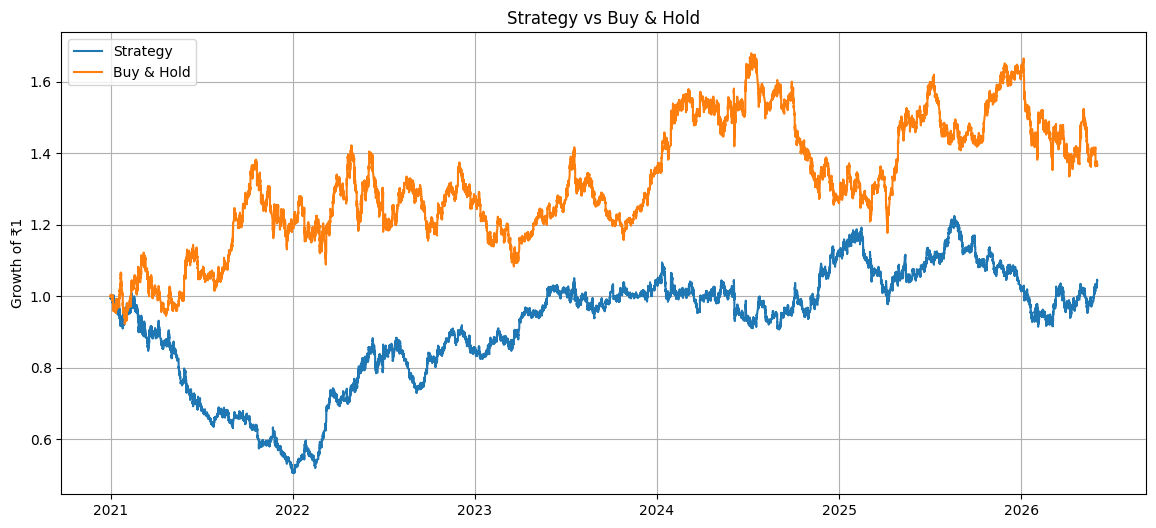

In [9]:
result = optimized_moving_average(spot, timeframe ='1min')

## **For 5 min timeframe**

2020 had Best SMA = 10 and Best LMA = 40
Tested for : 2021
2021 had Best SMA = 35 and Best LMA = 40
Tested for : 2022
2022 had Best SMA = 45 and Best LMA = 110
Tested for : 2023
2023 had Best SMA = 5 and Best LMA = 90
Tested for : 2024
2024 had Best SMA = 20 and Best LMA = 60
Tested for : 2025
2025 had Best SMA = 30 and Best LMA = 25
Tested for : 2026
simple_returns :176.71125461157646
sharpe :0.006629228482699589
max_drawdown :-0.28298355444170764
score :1.770201743023231


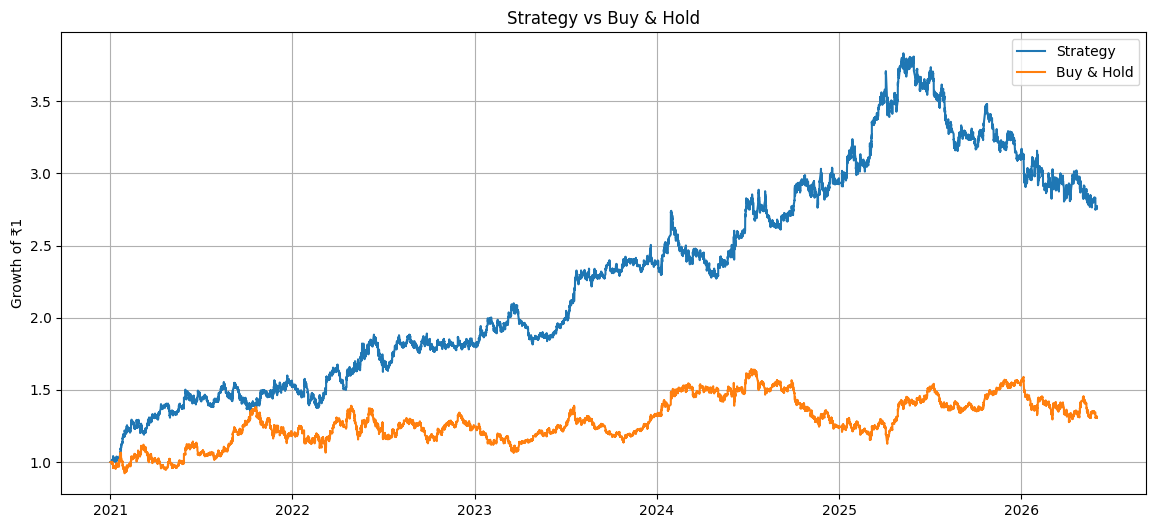

In [8]:
result = optimized_moving_average(spot, timeframe ='5min')

## **For 15 min timeframe**

2020 had Best SMA = 5 and Best LMA = 25
Tested for : 2021
2021 had Best SMA = 25 and Best LMA = 60
Tested for : 2022
2022 had Best SMA = 5 and Best LMA = 65
Tested for : 2023
2023 had Best SMA = 15 and Best LMA = 20
Tested for : 2024
2024 had Best SMA = 15 and Best LMA = 50
Tested for : 2025
2025 had Best SMA = 50 and Best LMA = 55
Tested for : 2026
simple_returns :284.9972885465287
sharpe :0.015359679463325247
max_drawdown :-0.363973483945938
score :1.3814062842499848


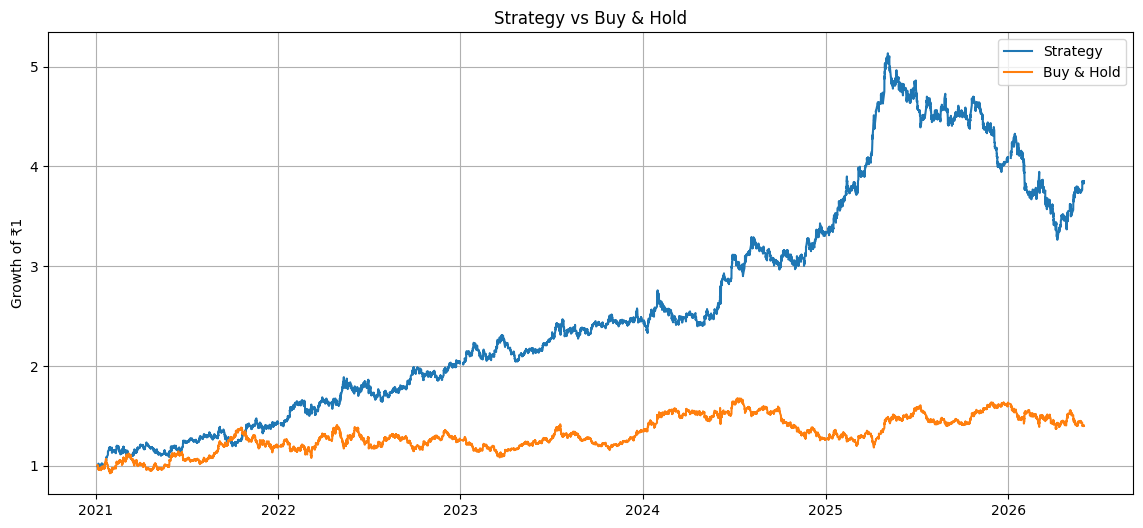

In [11]:
result = optimized_moving_average(spot, timeframe ='15min')

# **Conclusion**

The Strategy returns are more than Buy and Hold returns but the drawdown and sharpe ratio are unfavourable.

---

